# Phase 1: Environment Setup and Exploratory Data Analysis (EDA)

**Note:** The test dataset is strictly isolated and will not be analyzed to prevent data leakage.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

sns.set_theme(style="whitegrid")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ravin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1.1 Loading the Training Data and Basic Statistics

In [5]:
df_train = pd.read_csv('phm_train.csv')

print("--- Dataset Info ---")
print(df_train.info())
print("\n--- First 5 Rows ---")
display(df_train.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9991 entries, 0 to 9990
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  9991 non-null   float64
 1   label     9991 non-null   int64  
 2   tweet     9991 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 234.3+ KB
None

--- First 5 Rows ---


,tweet_id,label,tweet
0,6.430000e+17,0,user_mention all i can tell you is i have had ...
1,6.440000e+17,0,my doctor told me stop he gave me sum pop i mi...
2,8.150000e+17,1,i take tylenol and i wake up in the middle of ...
3,6.820000e+17,0,i got xans in an advil bottle i dont take them...
4,6.440000e+17,1,mom says i need to stop eating so much bc ive ...


In [6]:
print("\n--- Missing Values ---")
print(df_train.isnull().sum())


--- Missing Values ---
tweet_id    0
label       0
tweet       0
dtype: int64


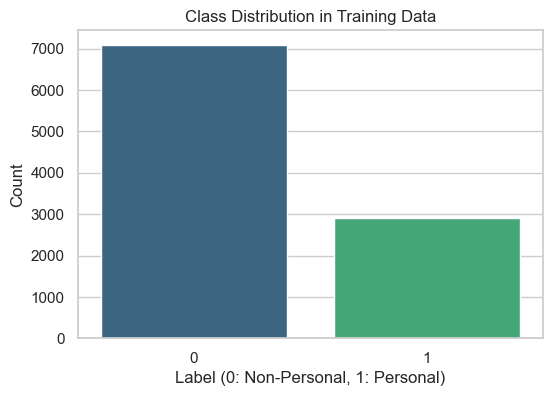


Class Counts:
label
0    70.973876
1    29.026124
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='label', hue='label', palette='viridis', legend=False)
plt.title('Class Distribution in Training Data')
plt.xlabel('Label (0: Non-Personal, 1: Personal)')
plt.ylabel('Count')
plt.show()

print("\nClass Counts:")
print(df_train['label'].value_counts(normalize=True) * 100) 

## 1.2 Word Count Analysis

In [8]:
df_train['word_count'] = df_train['tweet'].apply(lambda x: len(str(x).split()))

print("--- Overall Word Count Statistics ---")
print(df_train['word_count'].describe())

--- Overall Word Count Statistics ---
count    9991.000000
mean       15.567010
std         6.233004
min         5.000000
25%        10.000000
50%        15.000000
75%        21.000000
max        32.000000
Name: word_count, dtype: float64


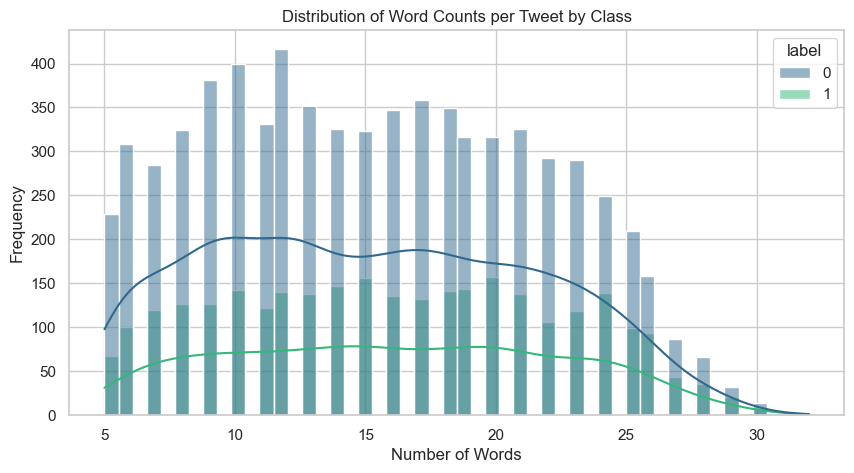

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_train, x='word_count', hue='label', bins=50, kde=True, palette='viridis')
plt.title('Distribution of Word Counts per Tweet by Class')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [10]:
df_class_0 = df_train[df_train['label'] == 0]
df_class_1 = df_train[df_train['label'] == 1]

print(f"\nAverage word count for Label 0: {df_class_0['word_count'].mean():.2f}")
print(f"Average word count for Label 1: {df_class_1['word_count'].mean():.2f}")


Average word count for Label 0: 15.35
Average word count for Label 1: 16.10


## 1.3 Vocabulary and Common Words Analysis

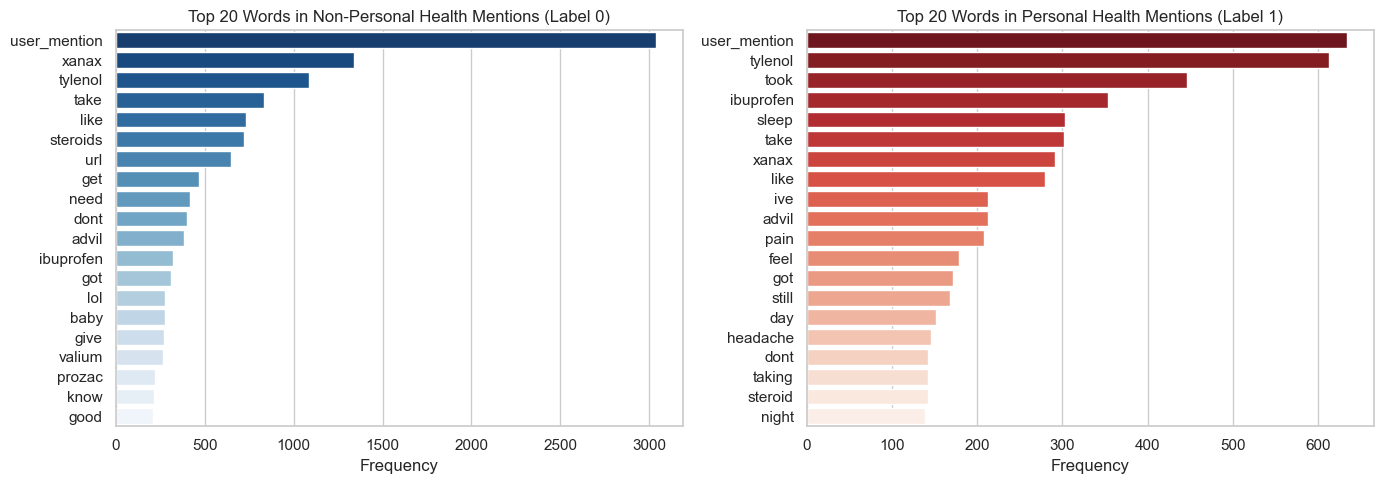

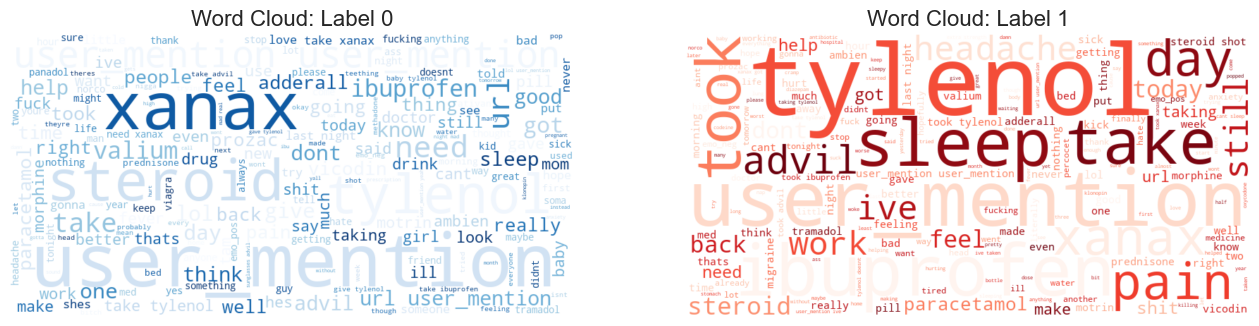

In [11]:
def get_most_common_words(text_series, num_words=20):
    all_words = ' '.join(text_series.astype(str)).lower().split()
    filtered_words = [word for word in all_words if word not in stop_words and len(word) > 2]
    word_freq = Counter(filtered_words)
    return word_freq.most_common(num_words), ' '.join(filtered_words)


common_0, text_0 = get_most_common_words(df_class_0['tweet'])
common_1, text_1 = get_most_common_words(df_class_1['tweet'])


x_0 = [val[1] for val in common_0]
y_0 = [val[0] for val in common_0]

x_1 = [val[1] for val in common_1]
y_1 = [val[0] for val in common_1]


plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

sns.barplot(x=x_0, y=y_0, hue=y_0, palette='Blues_r', legend=False)
plt.title('Top 20 Words in Non-Personal Health Mentions (Label 0)')
plt.xlabel('Frequency')


plt.subplot(1, 2, 2)
sns.barplot(x=x_1, y=y_1, hue=y_1, palette='Reds_r', legend=False)
plt.title('Top 20 Words in Personal Health Mentions (Label 1)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

wc_0 = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(text_0)
ax1.imshow(wc_0, interpolation='bilinear')
ax1.set_title('Word Cloud: Label 0', fontsize=16)
ax1.axis('off')

wc_1 = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_1)
ax2.imshow(wc_1, interpolation='bilinear')
ax2.set_title('Word Cloud: Label 1', fontsize=16)
ax2.axis('off')

plt.show()

# Phase 2: Text Preprocessing and PyTorch Dataset Setup

## 2.1 Python Code (Text Cleaning & Vocabulary Building)

In [12]:
import re
import emoji
import contractions
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Dataset, DataLoader

def clean_tweet_advanced(text):
    text = str(text)
    text = contractions.fix(text)
    text = emoji.demojize(text)
    text = text.replace(':', ' ')
    text = text.lower()
    text = re.sub(r'[^a-z0-9_ ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_train['clean_tweet'] = df_train['tweet'].apply(clean_tweet_advanced)

all_words = ' '.join(df_train['clean_tweet']).split()
word_counts = Counter(all_words)

min_freq = 2
vocab_words = [word for word, count in word_counts.items() if count >= min_freq]

word2idx = {'<PAD>': 0, '<UNK>': 1}
for idx, word in enumerate(vocab_words, start=2):
    word2idx[word] = idx

idx2word = {idx: word for word, idx in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f"Original vocabulary size: {len(word_counts)}")
print(f"Reduced vocabulary size (min_freq={min_freq}): {VOCAB_SIZE}")

sample_messy_tweet = "I don't feel well today 🤒 took some advil 💊"
print(f"\nBefore: {sample_messy_tweet}")
print(f"After : {clean_tweet_advanced(sample_messy_tweet)}")

Original vocabulary size: 12821
Reduced vocabulary size (min_freq=2): 5359

Before: I don't feel well today 🤒 took some advil 💊
After : i do not feel well today face_with_thermometer took some advil pill


## 2.2 Python Code (Tokenization and PyTorch Dataset)

In [13]:
MAX_LEN = 40

def encode_tweet(text, vocab, max_len):
    tokens = text.split()
    encoded = [vocab.get(word, 1) for word in tokens]
    
    if len(encoded) < max_len:
        encoded = encoded + [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
        
    return encoded

class TweetDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]
        
        encoded_text = encode_tweet(text, self.vocab, self.max_len)
        
        x_tensor = torch.tensor(encoded_text, dtype=torch.long)
        y_tensor = torch.tensor(label, dtype=torch.float32) 
        
        return x_tensor, y_tensor

sample_dataset = TweetDataset(df_train['clean_tweet'], df_train['label'], word2idx, MAX_LEN)
sample_x, sample_y = sample_dataset[0]
print("--- Dataset Output Test ---")
print(f"Original Text: {df_train['clean_tweet'].iloc[0]}")
print(f"Encoded Tensor: {sample_x}")
print(f"Label Tensor: {sample_y}")

--- Dataset Output Test ---
Original Text: user_mention all i can tell you is i have had few relapses on it it is not a cure i hear if you do not test for the jc virus tysabri is good
Encoded Tensor: tensor([ 2,  3,  4,  5,  6,  7,  8,  4,  9, 10, 11, 12, 13, 14, 14,  8, 15, 16,
        17,  4, 18, 19,  7, 20, 15, 21, 22, 23, 24, 25, 26,  8, 27,  0,  0,  0,
         0,  0,  0,  0])
Label Tensor: 0.0


## 2.3 Python Code (5-Fold Setup & Class Weights)

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_data = df_train['clean_tweet']
y_data = df_train['label']

class_0_count = len(df_train[df_train['label'] == 0])
class_1_count = len(df_train[df_train['label'] == 1])
total_count = len(df_train)

weight_for_0 = (1 / class_0_count) * (total_count / 2.0)
weight_for_1 = (1 / class_1_count) * (total_count / 2.0)

pos_weight = torch.tensor([weight_for_1 / weight_for_0]).to(device)

print(f"Calculated Positive Class Weight (Multiplier for Label 1): {pos_weight.item():.4f}")
print("5-Fold Cross Validation is ready for the training loop.")

Calculated Positive Class Weight (Multiplier for Label 1): 2.4452
5-Fold Cross Validation is ready for the training loop.


# Phase 3: Building the LSTM and Bi-LSTM Models

In [15]:
import torch
import torch.nn as nn

class AdvancedTweetClassifierLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, 
                 bidirectional, embed_drop, lstm_drop, fc_drop, fc_hidden_dim):
        super(AdvancedTweetClassifierLSTM, self).__init__()
        

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embed_dropout = nn.Dropout(embed_drop)
        
      
        self.lstm = nn.LSTM(embedding_dim, 
                            hidden_dim, 
                            num_layers=n_layers, 
                            bidirectional=bidirectional, 
                            dropout=lstm_drop if n_layers > 1 else 0,
                            batch_first=True)
        
        
        self.lstm_out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
       
        self.layer_norm = nn.LayerNorm(self.lstm_out_dim)
        
        
        self.fc_dropout = nn.Dropout(fc_drop)
        self.fc1 = nn.Linear(self.lstm_out_dim, fc_hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_hidden_dim, output_dim)
        
    def forward(self, text):
      
        embedded = self.embed_dropout(self.embedding(text))
        
        output, (hidden, cell) = self.lstm(embedded)
        
        pooled_output, _ = torch.max(output, dim=1)
        
        pooled_output = self.layer_norm(pooled_output)
        pooled_output = self.fc_dropout(pooled_output)
        
        dense_out = self.fc1(pooled_output)
        dense_out = self.relu(dense_out)
        dense_out = self.fc_dropout(dense_out)

        return self.fc2(dense_out)

print("Advanced LSTM with Global Max Pooling defined successfully!")

Advanced LSTM with Global Max Pooling defined successfully!


# Phase 4: Advanced Hyperparameter Tuning with Optuna

## 4.1 Python Code (Helper Functions & Metrics)

In [16]:
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score
from torch.cuda.amp import autocast, GradScaler
import optuna
import copy

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, logits=True, reduce=True):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        BCE_loss = self.bce_with_logits(inputs, targets)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

print("Advanced Metrics and Focal Loss ready.")

Advanced Metrics and Focal Loss ready.


## 4.2 Python Code (The Optuna Objective Function)

In [17]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score, accuracy_score
from torch.cuda.amp import autocast, GradScaler
import optuna
import numpy as np

MAX_EPOCHS = 10 

def objective(trial):
    embed_dim = trial.suggest_categorical('embedding_dim', [100, 200, 300]) 
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256]) 
    fc_hidden_dim = trial.suggest_categorical('fc_hidden_dim', [32, 64, 128])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True) 
    embed_drop = trial.suggest_float('embed_drop', 0.2, 0.6)
    lstm_drop = trial.suggest_float('lstm_drop', 0.2, 0.6)
    fc_drop = trial.suggest_float('fc_drop', 0.2, 0.6)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    is_bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    
    gamma = trial.suggest_float('gamma', 1.0, 3.0)
    
    fold_f1_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        
        train_texts, val_texts = X_data.iloc[train_idx], X_data.iloc[val_idx]
        train_labels, val_labels = y_data.iloc[train_idx], y_data.iloc[val_idx]
        
        train_dataset = TweetDataset(train_texts, train_labels, word2idx, MAX_LEN)
        val_dataset = TweetDataset(val_texts, val_labels, word2idx, MAX_LEN)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        model = AdvancedTweetClassifierLSTM(
            vocab_size=VOCAB_SIZE, 
            embedding_dim=embed_dim, 
            hidden_dim=hidden_dim, 
            output_dim=1, 
            n_layers=2,   
            bidirectional=is_bidirectional, 
            embed_drop=embed_drop, 
            lstm_drop=lstm_drop, 
            fc_drop=fc_drop, 
            fc_hidden_dim=fc_hidden_dim
        ).to(device)
        
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        scheduler = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
        
        criterion = FocalLoss(alpha=pos_weight.item(), gamma=gamma)
        scaler = GradScaler() 
        
        best_val_f1 = 0
        patience_counter = 0
        PATIENCE = 3
        
        for epoch in range(MAX_EPOCHS):
            model.train()
            for texts, labels in train_loader:
                texts, labels = texts.to(device), labels.to(device)
                optimizer.zero_grad()
                with autocast():
                    predictions = model(texts).squeeze(1)
                    loss = criterion(predictions, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                
            scheduler.step() 
            
            model.eval()
            all_preds, all_labels = [], []
            with torch.no_grad():
                for texts, labels in val_loader:
                    texts, labels = texts.to(device), labels.to(device)
                    with autocast():
                        predictions = model(texts).squeeze(1)
                    probs = torch.sigmoid(predictions)
                    preds = (probs > 0.5).float()
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
                    
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')
            
            if epoch_f1 > best_val_f1:
                best_val_f1 = epoch_f1
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= PATIENCE:
                break 
                
        fold_f1_scores.append(best_val_f1)
        
    return np.mean(fold_f1_scores)

print("Upgraded Optuna Objective Function ready!")

Upgraded Optuna Objective Function ready!


## 4.3 Python Code (Running the Optimization)

In [18]:
import warnings
warnings.filterwarnings('ignore') 

print("Starting Advanced Optuna Search with Early Stopping & AdamW...")

study = optuna.create_study(direction='maximize', study_name="Tweet_LSTM_Advanced_Tuning")

study.optimize(objective, n_trials=25)

print("\n=== ADVANCED OPTIMIZATION FINISHED ===")
print(f"Best Macro F1-Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

[I 2026-03-01 20:20:04,073] A new study created in memory with name: Tweet_LSTM_Advanced_Tuning


Starting Advanced Optuna Search with Early Stopping & AdamW...


[I 2026-03-01 20:23:07,319] Trial 0 finished with value: 0.7349229039184968 and parameters: {'embedding_dim': 100, 'hidden_dim': 256, 'fc_hidden_dim': 64, 'lr': 0.00010931223797726832, 'weight_decay': 0.0003585571215430628, 'embed_drop': 0.5224541451506037, 'lstm_drop': 0.25500941268092764, 'fc_drop': 0.32769139033350425, 'batch_size': 64, 'bidirectional': True, 'gamma': 2.1385381262649386}. Best is trial 0 with value: 0.7349229039184968.
[I 2026-03-01 20:27:03,189] Trial 1 finished with value: 0.7979072301830955 and parameters: {'embedding_dim': 100, 'hidden_dim': 256, 'fc_hidden_dim': 32, 'lr': 0.00033879962461157034, 'weight_decay': 7.45442342631186e-05, 'embed_drop': 0.38411304776156796, 'lstm_drop': 0.24501825796254573, 'fc_drop': 0.3037006262383604, 'batch_size': 32, 'bidirectional': False, 'gamma': 1.6446532231389692}. Best is trial 1 with value: 0.7979072301830955.
[I 2026-03-01 20:27:50,043] Trial 2 finished with value: 0.722691144151195 and parameters: {'embedding_dim': 200, 


=== ADVANCED OPTIMIZATION FINISHED ===
Best Macro F1-Score: 0.8188
Best Hyperparameters:
    embedding_dim: 300
    hidden_dim: 256
    fc_hidden_dim: 32
    lr: 0.0031211170983288052
    weight_decay: 3.4013355922825807e-05
    embed_drop: 0.5984435787610937
    lstm_drop: 0.3895735526295105
    fc_drop: 0.26012005216339595
    batch_size: 128
    bidirectional: True
    gamma: 2.4601944153295756


# Phase 5: Final Model Training, Comparison, and Saving

--- Preparing 100% Train and Test Data ---

   Training & Testing Model: Standard LSTM
Epoch 01/30 | Train Loss: 0.2565 | Test Loss: 0.2171 | Test Acc: 0.7613  <-- [NEW BEST TEST ACCURACY SAVED]
Epoch 02/30 | Train Loss: 0.2292 | Test Loss: 0.1973 | Test Acc: 0.7887  <-- [NEW BEST TEST ACCURACY SAVED]
Epoch 03/30 | Train Loss: 0.2136 | Test Loss: 0.1858 | Test Acc: 0.8070  <-- [NEW BEST TEST ACCURACY SAVED]
Epoch 04/30 | Train Loss: 0.2057 | Test Loss: 0.1885 | Test Acc: 0.7947
Epoch 05/30 | Train Loss: 0.1971 | Test Loss: 0.1841 | Test Acc: 0.8118  <-- [NEW BEST TEST ACCURACY SAVED]
Epoch 06/30 | Train Loss: 0.1949 | Test Loss: 0.1766 | Test Acc: 0.8226  <-- [NEW BEST TEST ACCURACY SAVED]
Epoch 07/30 | Train Loss: 0.1858 | Test Loss: 0.1846 | Test Acc: 0.8055
Epoch 08/30 | Train Loss: 0.1815 | Test Loss: 0.1705 | Test Acc: 0.8256  <-- [NEW BEST TEST ACCURACY SAVED]
Epoch 09/30 | Train Loss: 0.1768 | Test Loss: 0.1816 | Test Acc: 0.8277  <-- [NEW BEST TEST ACCURACY SAVED]
Epoch 10/30 |

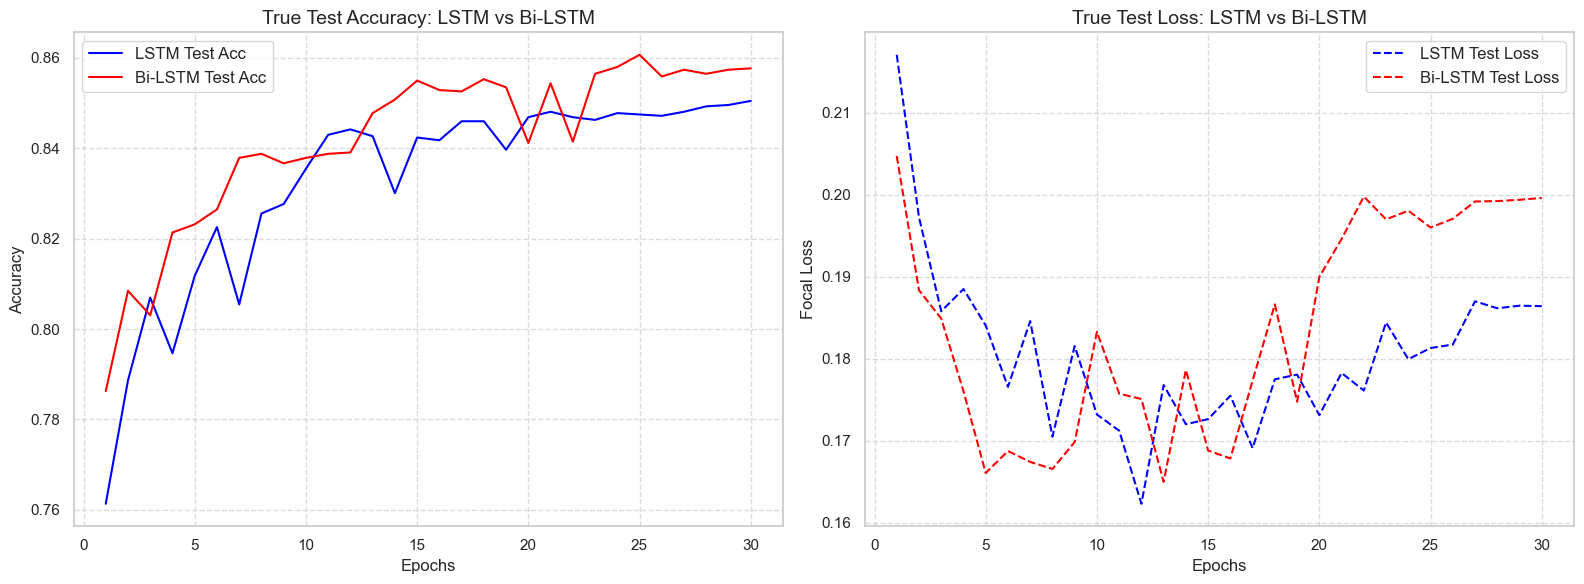

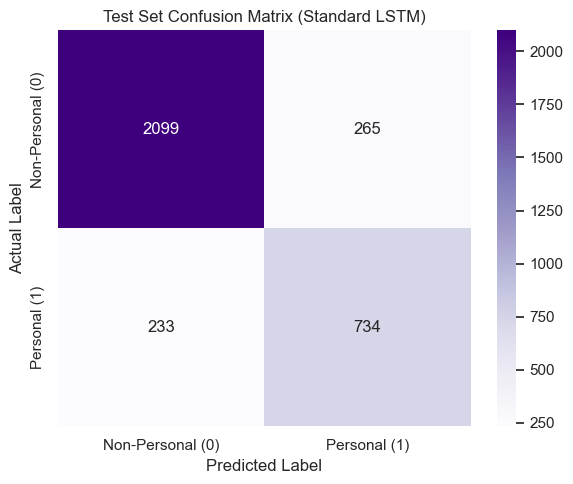

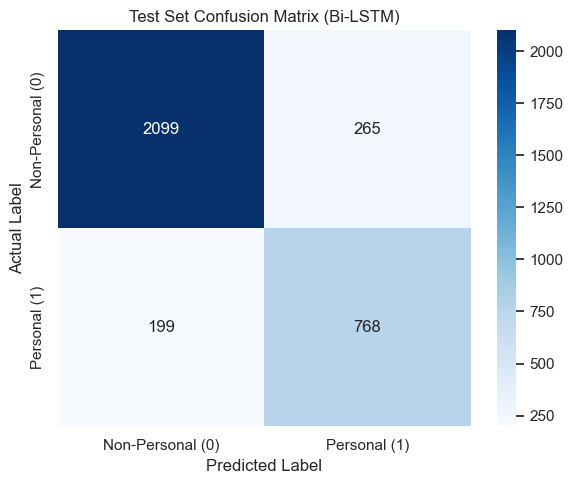


>>> All plots and predictions successfully saved!


In [26]:
import pandas as pd
import torch
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import copy

BEST_PARAMS = study.best_params

print("--- Preparing 100% Train and Test Data ---")
df_test = pd.read_csv('phm_test.csv')
df_test = df_test.dropna(subset=['tweet']).reset_index(drop=True) 

df_test['clean_tweet'] = df_test['tweet'].apply(clean_tweet_advanced)

train_dataset_final = TweetDataset(df_train['clean_tweet'], df_train['label'], word2idx, MAX_LEN)
test_dataset_final = TweetDataset(df_test['clean_tweet'], df_test['label'], word2idx, MAX_LEN)

train_loader_final = DataLoader(train_dataset_final, batch_size=BEST_PARAMS['batch_size'], shuffle=True)
test_loader_final = DataLoader(test_dataset_final, batch_size=BEST_PARAMS['batch_size'], shuffle=False)

FINAL_EPOCHS = 30 

def train_and_evaluate_model(is_bidirectional, model_name, save_filename):
    print(f"\n======================================================")
    print(f"   Training & Testing Model: {model_name}")
    print(f"======================================================")
    
    model = AdvancedTweetClassifierLSTM(
        vocab_size=VOCAB_SIZE,
        embedding_dim=BEST_PARAMS['embedding_dim'],
        hidden_dim=BEST_PARAMS['hidden_dim'],
        output_dim=1,
        n_layers=2,
        bidirectional=is_bidirectional,
        embed_drop=BEST_PARAMS['embed_drop'],
        lstm_drop=BEST_PARAMS['lstm_drop'],
        fc_drop=BEST_PARAMS['fc_drop'],
        fc_hidden_dim=BEST_PARAMS['fc_hidden_dim']
    ).to(device)
    
    # For final training, we reduce the learning rate to 15% for better convergence 
    optimizer = optim.AdamW(model.parameters(), lr=BEST_PARAMS['lr'] *0.15, weight_decay=BEST_PARAMS['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)
    criterion = FocalLoss(alpha=pos_weight.item(), gamma=BEST_PARAMS['gamma'])
    scaler = GradScaler()
    
    history = {'train_loss': [], 'test_loss': [], 'test_acc': [], 'train_acc': []}
    
    best_test_acc = 0.0
    best_model_weights = None
    best_epoch = 0
    best_test_preds = []
    best_test_labels = []
    
    for epoch in range(FINAL_EPOCHS):
        model.train()
        epoch_train_loss = 0
        all_train_preds, all_train_labels = [], []
        
        for texts, labels in train_loader_final:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                predictions = model(texts).squeeze(1)
                loss = criterion(predictions, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_train_loss += loss.item()
            
            probs = torch.sigmoid(predictions)
            preds = (probs > 0.5).float()
            all_train_preds.extend(preds.detach().cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            
        scheduler.step()
        avg_train_loss = epoch_train_loss / len(train_loader_final)
        train_acc = accuracy_score(all_train_labels, all_train_preds)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        
        model.eval()
        epoch_test_loss = 0
        all_test_preds, all_test_labels = [], []
        
        with torch.no_grad():
            for texts, labels in test_loader_final:
                texts, labels = texts.to(device), labels.to(device)
                with autocast():
                    predictions = model(texts).squeeze(1)
                    test_loss = criterion(predictions, labels)
                
                epoch_test_loss += test_loss.item()
                probs = torch.sigmoid(predictions)
                preds = (probs > 0.5).float()
                
                all_test_preds.extend(preds.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())
                
        avg_test_loss = epoch_test_loss / len(test_loader_final)
        test_acc = accuracy_score(all_test_labels, all_test_preds)
        
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_acc)
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            best_test_preds = all_test_preds
            best_test_labels = all_test_labels
            save_msg = "  <-- [NEW BEST TEST ACCURACY SAVED]"
        else:
            save_msg = ""
            
        print(f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.4f}{save_msg}")
    
    torch.save(best_model_weights, save_filename)
    print(f"\n>>> Finished! Saved {model_name} from Epoch {best_epoch} (Acc: {best_test_acc:.4f}) as '{save_filename}'")
    
    print(f"\nFinal Classification Report for {model_name}:")
    print(classification_report(best_test_labels, best_test_preds, target_names=['Non-Personal (0)', 'Personal (1)']))
    
    return history, best_test_preds, best_test_labels

history_lstm, lstm_preds, test_labels = train_and_evaluate_model(False, "Standard LSTM", "LSTM_final_model.pth")
history_bilstm, bilstm_preds, _ = train_and_evaluate_model(True, "Bi-LSTM", "BiLSTM_final_model.pth")

epochs_range = range(1, FINAL_EPOCHS + 1)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_lstm['test_acc'], label='LSTM Test Acc', color='blue')
plt.plot(epochs_range, history_bilstm['test_acc'], label='Bi-LSTM Test Acc', color='red')
plt.title('True Test Accuracy: LSTM vs Bi-LSTM', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_lstm['test_loss'], label='LSTM Test Loss', color='blue', linestyle='--')
plt.plot(epochs_range, history_bilstm['test_loss'], label='Bi-LSTM Test Loss', color='red', linestyle='--')
plt.title('True Test Loss: LSTM vs Bi-LSTM', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Focal Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300)
plt.show()

def plot_cm(labels, preds, name, filename, cmap):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=['Non-Personal (0)', 'Personal (1)'], yticklabels=['Non-Personal (0)', 'Personal (1)'])
    plt.title(f'Test Set Confusion Matrix ({name})')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_cm(test_labels, lstm_preds, "Standard LSTM", "confusion_matrix_LSTM.png", 'Purples')
plot_cm(test_labels, bilstm_preds, "Bi-LSTM", "confusion_matrix_BiLSTM.png", 'Blues')

df_test['LSTM_prediction'] = [int(p) for p in lstm_preds]
df_test['BiLSTM_prediction'] = [int(p) for p in bilstm_preds]
df_test.to_csv('phm_test_predictions_final.csv', index=False)
print("\n>>> All plots and predictions successfully saved!")